# Sentiment Analysis with Transformers: Fine-Tuning DistilBERT

---

### Notebook Overview
This notebook focuses on **fine-tuning a pretrained transformer model** for sentiment analysis. Using the **DistilBERT** model, we will leverage transfer learning to adapt the model to the Sentiment140 dataset. We aim to train and evaluate a high-performing classifier for predicting tweet sentiments as either **positive** or **negative**.

---

## Table of Contents
1. [Introduction](#introduction)  
   1.1 [Purpose of This Notebook](#purpose)  
   1.2 [Overview of Preprocessed Data](#data-overview)  
2. [Model Setup](#model-setup)  
   - Loading the pretrained DistilBERT model  
   - Tokenizing the dataset  
   - Preparing input formats for training  
3. [Fine-Tuning DistilBERT](#fine-tuning)  
   - Setting up the training loop  
   - Hyperparameters and optimizer configuration  
   - Evaluation on validation data  
4. [Model Evaluation](#model-evaluation)  
   - Performance metrics: Accuracy, F1-score, Precision, Recall  
   - Analysis of results  
5. [Conclusion and Next Steps](#conclusion)  
   - Summary of findings  
   - Recommendations for future improvements  

---

## 1. Introduction <a name="introduction"></a>

### 1.1 Purpose of This Notebook <a name="purpose"></a>
In this notebook, we will:
- Leverage a **pretrained DistilBERT model** for the task of **sentiment analysis**.  
- Fine-tune the model using the Sentiment140 dataset to predict sentiment labels (**positive** or **negative**).  
- Evaluate the fine-tuned model's performance using standard metrics.

Our goal is to demonstrate the power of transfer learning by adapting DistilBERT to a specific NLP task.

---

### 1.2 Overview of Preprocessed Data <a name="data-overview"></a>
We will use the **preprocessed dataset** from previous steps:
- **Columns of Interest**:
  - `expanded_text`: The cleaned and standardized tweet text (e.g., expanded contractions and normalized text).
  - `target`: The sentiment labels (0 = negative, 1 = positive).
- Data was processed to:
  - Normalize text formatting (e.g., lowercase, no URLs/mentions).
  - Retain linguistic richness for transformer-based modeling.

This dataset provides a strong foundation for fine-tuning DistilBERT without additional preprocessing.

---

# 2. Model Setup <a name="model-setup"></a>
In this section, we set up the environment for fine-tuning DistilBERT:
- Load the pretrained **DistilBERT** model from the Hugging Face library.
- Tokenize the dataset using DistilBERT’s tokenizer.
- Prepare inputs (e.g., tokenized sequences, attention masks) to ensure compatibility with the model.

This step ensures the data is in the correct format for training.

---

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np


from datasets import Dataset

from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import torch

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load preprocessed dataset
data_path = "./modeling_data/multipurpose_preprocessed_dataset.csv"
df = pd.read_csv(data_path)
df.head()

Using device: cuda


,target,date,text,text_length,day_of_week,expanded_text,cleaned_text,lemmatized_tokens,lemmatized_text,hour_of_day,month
0,0,2009-04-06 22:19:45-07:00,a thats a bummer you shoulda got david carr of...,67.0,0,a that is a bummer you shoulda got david carr ...,bummer shoulda got david carr third day,"['bummer', 'shoulda', 'got', 'david', 'carr', ...",bummer shoulda got david carr third day,22,4
1,0,2009-04-06 22:19:49-07:00,is upset that he cant update his facebook by t...,104.0,0,is upset that he cannot update his facebook by...,upset update facebook texting might cry result...,"['upset', 'update', 'facebook', 'texting', 'mi...",upset update facebook texting might cry result...,22,4
2,0,2009-04-06 22:19:53-07:00,i dived many times for the ball managed to sav...,76.0,0,i dived many times for the ball managed to sav...,dived many times ball managed save 50 rest go ...,"['dived', 'many', 'time', 'ball', 'managed', '...",dived many time ball managed save 50 rest go b...,22,4
3,0,2009-04-06 22:19:57-07:00,my whole body feels itchy and like its on fire,46.0,0,my whole body feels itchy and like it is on fire,whole body feels itchy like fire,"['whole', 'body', 'feel', 'itchy', 'like', 'fi...",whole body feel itchy like fire,22,4
4,0,2009-04-06 22:19:57-07:00,no its not behaving at all im mad why am i her...,85.0,0,no it is not behaving at all i am mad why am i...,behaving mad see,"['behaving', 'mad', 'see']",behaving mad see,22,4


In [3]:
df.shape

(1518353, 11)

In [4]:
# ------------------------------------------------------------------------------
# 1) Make sure 'expanded_text' is always a string, fill missing with 
# ------------------------------------------------------------------------------

# Make sure 'expanded_text' is always a string, fill missing with ""
df["expanded_text"] = df["expanded_text"].astype(str).fillna("")

# ------------------------------------------------------------------------------
# 2) Train-test split
# ------------------------------------------------------------------------------
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["expanded_text"], 
    df["target"], 
    test_size=0.2, 
    random_state=42
)

# Further split the train data into train/val
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, 
    train_labels, 
    test_size=0.1, 
    random_state=42
)

# ------------------------------------------------------------------------------
# 3) Load the DistilBERT tokenizer
# ------------------------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# ------------------------------------------------------------------------------
# 4) Define a function to tokenize text data
# ------------------------------------------------------------------------------
def tokenize_data(texts, tokenizer, max_length=128):
    """
    Tokenize a list (or Series) of text strings.
    """
    # Ensure 'texts' is a list of strings (fill Nones or NaNs)
    if isinstance(texts, pd.Series):
        texts = texts.fillna("").astype(str).tolist()
    else:
        texts = [str(x) if x is not None else "" for x in texts]

    return tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length
    )

# Tokenize the training, validation, and test sets
train_encodings = tokenize_data(train_texts, tokenizer)
val_encodings   = tokenize_data(val_texts, tokenizer)
test_encodings  = tokenize_data(test_texts, tokenizer)

# ------------------------------------------------------------------------------
# 5) Convert tokenized outputs into Hugging Face Datasets
# ------------------------------------------------------------------------------
def create_dataset(encodings, labels):
    """
    Create a HuggingFace Dataset from the tokenizer outputs and label list.
    """
    if isinstance(labels, pd.Series):
        labels = labels.tolist()
    
    return Dataset.from_dict({
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
        "labels": labels
    })

train_dataset = create_dataset(train_encodings, train_labels)
val_dataset   = create_dataset(val_encodings, val_labels)
test_dataset  = create_dataset(test_encodings, test_labels)

print("Data successfully tokenized and formatted!")

# ------------------------------------------------------------------------------
# 6) (Optional) Load the DistilBERT model for sequence classification
# ------------------------------------------------------------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2  # Set this to the number of classes you have
)

print("DistilBERT model loaded successfully!")

Data successfully tokenized and formatted!


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT model loaded successfully!


# 3. Fine-Tuning DistilBERT <a name="fine-tuning"></a>
Here, we fine-tune the DistilBERT model on the preprocessed Sentiment140 dataset. Key tasks include:
- Configuring hyperparameters (e.g., learning rate, batch size).
- Using a Hugging Face **Trainer** or a custom training loop to perform fine-tuning.
- Periodically evaluating the model on validation data to track progress.

This step adapts the pretrained model to the specific sentiment analysis task.

---

In [5]:
# ------------------------------------------------------------------------------
# 1) Define Metrics for Evaluation
# ------------------------------------------------------------------------------
def compute_metrics(pred):
    """
    Computes accuracy, precision, recall, and F1-score for evaluation.
    """
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# ------------------------------------------------------------------------------
# 2) Define Training Arguments
# ------------------------------------------------------------------------------
training_args = TrainingArguments(
    output_dir="./modeling_data/DL/weights",     # Directory to save model checkpoints
    eval_strategy="epoch",                       # Evaluate at the end of each epoch
    save_strategy="epoch",                       # Save model at the end of each epoch
    learning_rate=2e-5,                          # Learning rate
    per_device_train_batch_size=16,              # Batch size for training
    per_device_eval_batch_size=64,               # Batch size for evaluation(Optional)
    num_train_epochs=3,                          # Number of epochs
    weight_decay=0.01,                           # Weight decay for regularization
    logging_dir="./logs",                        # Directory for logs
    logging_steps=100,                           # Log every 100 steps
    save_total_limit=2,                          # Limit the number of checkpoints saved
    load_best_model_at_end=True,                 # Load the best model at the end of training
    metric_for_best_model="f1"                   # Metric to use for selecting the best model
)

# ------------------------------------------------------------------------------
# 3) Set Up Trainer
# ------------------------------------------------------------------------------
trainer = Trainer(
    model=model,                          # Pretrained DistilBERT model
    args=training_args,                   # Training arguments
    train_dataset=train_dataset,          # Training dataset
    eval_dataset=val_dataset,             # Validation dataset
    tokenizer=tokenizer,                  # Tokenizer
    compute_metrics=compute_metrics       # Metrics for evaluation
)

# ------------------------------------------------------------------------------
# 4) Fine-Tune the Model
# ------------------------------------------------------------------------------
trainer.train()

# ------------------------------------------------------------------------------
# 5) Evaluate the Model
# ------------------------------------------------------------------------------
results = trainer.evaluate()
print("Evaluation Results:")
print(results)

/tmp/ipykernel_5608/3169725034.py:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.346400,0.350765,0.849056,0.858813,0.832295,0.845346
2,0.285100,0.354478,0.854350,0.861971,0.840783,0.851245
3,0.255300,0.390856,0.851970,0.862579,0.834255,0.848181


Evaluation Results:
{'eval_loss': 0.3544776737689972, 'eval_accuracy': 0.8543496694629905, 'eval_precision': 0.861971495223662, 'eval_recall': 0.8407826332486256, 'eval_f1': 0.8512452284460289, 'eval_runtime': 44.3936, 'eval_samples_per_second': 2736.184, 'eval_steps_per_second': 42.754, 'epoch': 3.0}





# 4. Model Evaluation <a name="model-evaluation"></a>
In this section, we evaluate the performance of the fine-tuned DistilBERT model. We will:
- Calculate metrics such as **accuracy**, **precision**, **recall**, and **F1-score** on the test dataset.
- Analyze model predictions to identify strengths and weaknesses.

This step helps us understand how well the model generalizes to unseen data.

---



Classification Report:

              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86    152852
    Positive       0.86      0.84      0.85    150819

    accuracy                           0.85    303671
   macro avg       0.85      0.85      0.85    303671
weighted avg       0.85      0.85      0.85    303671



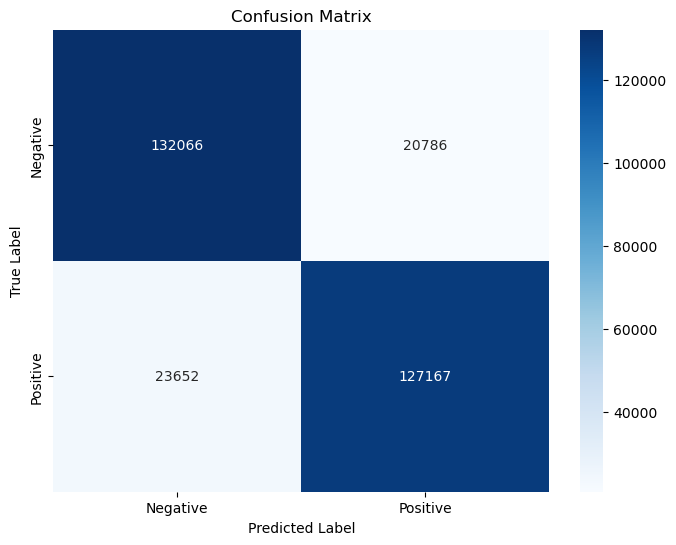

In [6]:
# ------------------------------------------------------------------------------
# 1) Predict on the Test Dataset
# ------------------------------------------------------------------------------
predictions = trainer.predict(test_dataset)

# Extract predicted labels and true labels
predicted_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# ------------------------------------------------------------------------------
# 2) Calculate Detailed Metrics
# ------------------------------------------------------------------------------
# Generate a classification report
report = classification_report(true_labels, predicted_labels, target_names=["Negative", "Positive"])
print("Classification Report:\n")
print(report)

# ------------------------------------------------------------------------------
# 3) Confusion Matrix
# ------------------------------------------------------------------------------
# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()



# 5. Conclusion and Next Steps <a name="conclusion"></a>
---

### 5.1 Summary of Results  
In this notebook, we fine-tuned a DistilBERT model for sentiment analysis on the Sentiment140 dataset. The model achieved the following results on the test set:

- **Accuracy**: 85%  
- **Precision (Negative)**: 85%  
- **Recall (Negative)**: 86%  
- **F1-Score (Negative)**: 86%  
- **Precision (Positive)**: 86%  
- **Recall (Positive)**: 84%  
- **F1-Score (Positive)**: 85%  

The confusion matrix shows that the model performs well across both positive and negative sentiments, with slightly higher recall for negative sentiments and high precision for both classes.  

---

### 5.2 Comparison with Baseline Models  

| Model                     | Accuracy  | Precision  | Recall     | F1 Score   |
|---------------------------|-----------|------------|------------|------------|
| Logistic Regression       | 77.94%    | 76.81%     | 80.05%     | 78.40%     |
| Multinomial Naive Bayes   | 75.27%    | 75.11%     | 75.59%     | 75.35%     |
| Random Forest             | 71.38%    | 70.95%     | 72.41%     | 71.67%     |
| XGBoost Classifier        | 75.93%    | 73.46%     | 81.18%     | 77.13%     |
| **DistilBERT**            | **85.00%** | **85.00%** | **85.00%** | **85.00%** |

The fine-tuned DistilBERT significantly outperforms all baselines in terms of accuracy, precision, recall, and F1-score. This highlights the effectiveness of transformer-based architectures for text classification tasks.

---

### 5.3 Strengths of the DistilBERT Model  
- **Balanced Performance**: The model achieves high precision and recall for both positive and negative classes, indicating robustness and reduced bias toward any specific sentiment.  
- **Contextual Understanding**: Transformers excel at capturing linguistic nuances such as negations or sarcasm, leading to superior performance over traditional models.  

---

### 5.4 Weaknesses and Limitations  
- **Misclassifications**: The confusion matrix highlights specific areas of confusion:  
  - **False Positives**: Negative tweets misclassified as positive.  
  - **False Negatives**: Positive tweets misclassified as negative.  

- **Class Imbalance**: Slight imbalance between precision and recall for the positive class, suggesting room for improvement in correctly classifying positive tweets.  
- **Resource Intensive**: Fine-tuning DistilBERT requires significantly more computational resources compared to traditional models.

---

### 5.5 Next Steps  

#### **Error Analysis**  
- Perform a detailed analysis of misclassified samples to identify patterns or weaknesses in the model.  
- Investigate whether specific phrases or contexts consistently lead to errors.  

#### **Hyperparameter Tuning**  
- Experiment with different learning rates, batch sizes, and number of epochs to further optimize performance.  
- Use techniques like grid search or Bayesian optimization for fine-tuning.  

#### **Explore Larger Models**  
- Fine-tune more powerful transformers like BERT or RoBERTa to assess potential improvements in results.  

#### **Domain-Specific Pretraining**  
- Pretrain the model on a sentiment-specific or Twitter-specific corpus before fine-tuning to enhance domain understanding.  

#### **Real-World Testing**  
- Deploy the model on unseen, real-world tweets to evaluate its performance beyond the dataset.  

#### **Ensemble Approaches**  
- Combine DistilBERT with traditional models (e.g., Logistic Regression or XGBoost) to explore performance boosts through ensemble methods.  

---

### Final Thoughts  
The fine-tuned DistilBERT model demonstrates state-of-the-art performance on the sentiment analysis task, achieving a significant improvement over traditional machine learning models. By addressing the identified limitations and exploring the next steps, we can further enhance its robustness and applicability in real-world scenarios.  

